## Lorenz63 Benchmarks

### config


In [ ]:
import torch
import matplotlib.pyplot as plt 
from lorenz import Lorenz63, TimeAveragedFeatures

N = 500
T = 360
spinup = 30
dt = 0.01
params = {
    'sigma':10,
    'beta':8/3,
    'rho':28 
}
l63 = Lorenz63(**params)
x0 = torch.randn((N,3))
r = l63(x0,T,dt)
l63_avg = TimeAveragedFeatures(l63,spinup=spinup)

r_avg = l63_avg(x0,T,dt)


In [2]:
r_avg_norm = (r_avg - r_avg.mean(dim=0))/r_avg.std(dim=0)

In [3]:
from lorenz import get_polynomial_features
spunup0 = get_polynomial_features(r[0,int(spinup/dt):])
t = int(10/dt)

In [4]:
chunks = spunup0.reshape(int((T-spinup)/(dt*t)), t, 9)
chunk_mean = chunks.mean(axis=1)

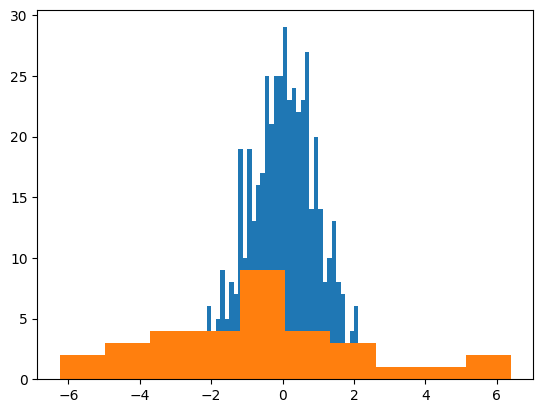

In [5]:

with torch.no_grad():
    plt.hist(r_avg_norm[:,0],bins=50)
    plt.hist(chunk_mean[:,0],bins=10)

In [6]:
from torch.distributions import MultivariateNormal
stats = MultivariateNormal(r_avg_norm.mean(dim=0),torch.cov(r_avg_norm.T))
true_cov = torch.cov(r_avg_norm.T) * (T - spinup)

In [7]:
noise_level = torch.sqrt(torch.linalg.eigh(torch.cov(r_avg.T)).eigenvalues.max())

### calibration

In [8]:
from torch.distributions import MultivariateNormal,Uniform
from abracalibra.forward_model import ForwardModel

priors = {
    'sigma':Uniform(5,15),
    'beta':Uniform(1,5),
    'rho':Uniform(25,30)
} # these are probably too wide priors!


N = 1
x0 = torch.randn((N,3))

def lorenz63(sigma,beta,rho):
    with torch.no_grad():
        l = TimeAveragedFeatures(Lorenz63(sigma,beta,rho),spinup=spinup)
        fwd = l(x0,T,dt)
        return (fwd[0] - r_avg.mean(dim=0))/(r_avg.std(dim=0))

fwd = ForwardModel(lorenz63,vectorized=False)

In [9]:
from abracalibra.history_matching import HistoryMatchingBase
from gpytorch.mlls import ExactMarginalLogLikelihood
from abracalibra.emulators import MultiTaskGP
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.priors import NormalPrior

class HistoryMatchingLorenz(HistoryMatchingBase):
    def make_emulator(self, parameters, observations):
        if self.output_mc_batchshape:
            target_shape = torch.Size((*parameters.shape[:-1], *self.output_mc_batchshape, self.number_of_parameters))
            parameters = parameters.unsqueeze(-2).expand(*target_shape)
            parameters = parameters.reshape(-1, self.number_of_parameters)
        else:
            parameters = parameters.view(-1, self.number_of_parameters)
        observations = observations.view(-1, self.number_of_observables)
        likelihood = MultitaskGaussianLikelihood(
            num_tasks=self.number_of_observables,
            has_task_noise=False,
            noise_prior=NormalPrior(1,0.001)

        )
        likelihood.noise = 1 
        model = MultiTaskGP(
            parameters,
            observations,
            likelihood=likelihood,
            num_tasks=self.number_of_observables,
        ).float()
        optim = torch.optim.Adam(model.parameters(), lr=0.05)
        mll = ExactMarginalLogLikelihood(likelihood, model)
        for i in range(250):
            optim.zero_grad()
            output = model(parameters)
            loss = -mll(output, observations)
            loss.backward()
            optim.step()
            print(f"Step {i} Loss: {loss.item()}")
        model.eval()
        return model

/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
from abracalibra.eki import EnsembleKalmanInversion
from scipy.stats import chi2
from abracalibra.summary import implausibility_multivariate_distr
parameters = ['sigma','beta','rho']
def summary(y,true_y):
    return torch.max(torch.abs(y.mean - true_y.mean)/torch.sqrt(y.variance + true_y.variance),dim=-1).values

priors = {
    'sigma':Uniform(9,11),
    'beta':Uniform(2,3),
    'rho':Uniform(25,30)
} # th
cutoff = chi2(stats.mean.shape[0]).ppf(0.95)
hm = HistoryMatchingLorenz(parameters,priors,stats,ensemble_size=30,summary=summary,forward=fwd,implausibility_cutoff=3)
hm.calibrate(3)

Step 0 Loss: 288.6767883300781
Step 1 Loss: 277.58843994140625
Step 2 Loss: 270.557373046875
Step 3 Loss: 264.17059326171875
Step 4 Loss: 256.784423828125
Step 5 Loss: 249.251708984375
Step 6 Loss: 242.39208984375
Step 7 Loss: 236.4443359375
Step 8 Loss: 231.09083557128906
Step 9 Loss: 225.87884521484375
Step 10 Loss: 220.66180419921875
Step 11 Loss: 215.595947265625
Step 12 Loss: 210.92587280273438
Step 13 Loss: 206.78016662597656
Step 14 Loss: 203.08653259277344
Step 15 Loss: 199.64187622070312
Step 16 Loss: 196.26007080078125
Step 17 Loss: 192.8874053955078
Step 18 Loss: 189.5709991455078
Step 19 Loss: 186.3573760986328
Step 20 Loss: 183.22628784179688
Step 21 Loss: 180.07736206054688
Step 22 Loss: 176.7943572998047
Step 23 Loss: 173.31622314453125
Step 24 Loss: 169.6577911376953
Step 25 Loss: 165.88204956054688
Step 26 Loss: 162.03797912597656
Step 27 Loss: 158.1295928955078
Step 28 Loss: 154.12225341796875
Step 29 Loss: 149.98385620117188
Step 30 Loss: 145.7211456298828
Step 31 Lo

In [11]:
hm.nroy(torch.tensor([10,8/3,28]),1)

tensor([True])

In [12]:
hm.nroy(torch.tensor([10,8/3,28]),2)


tensor([True])

In [13]:
hm.nroy(torch.tensor([10,8/3,28]),3)

tensor([True])

In [14]:
hm.estimate_nroy_volume(1)

tensor(0.0053)

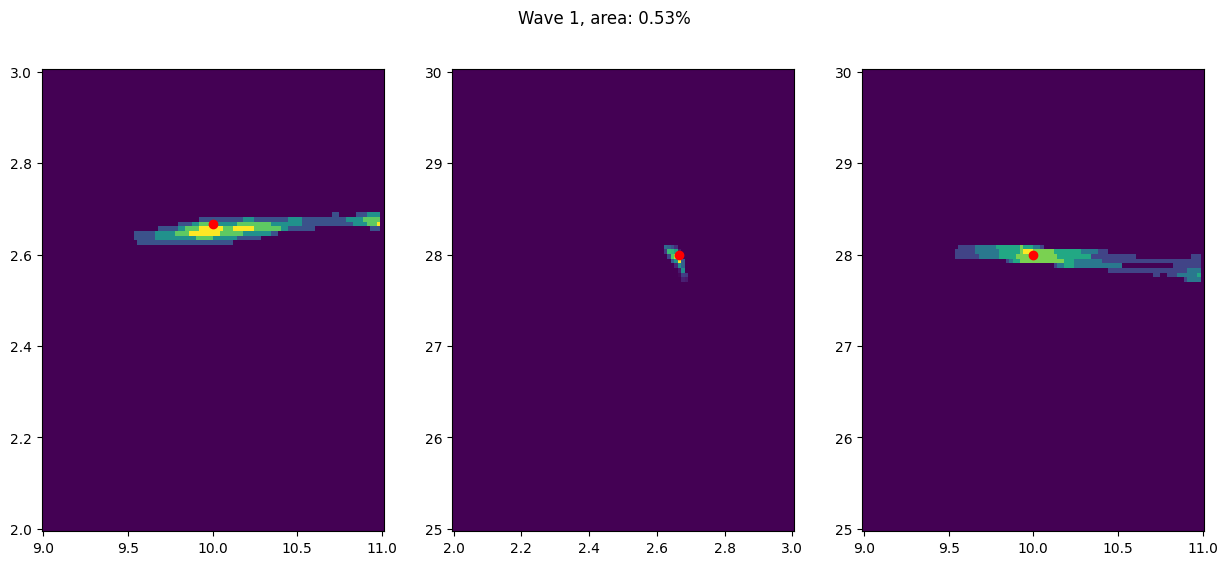

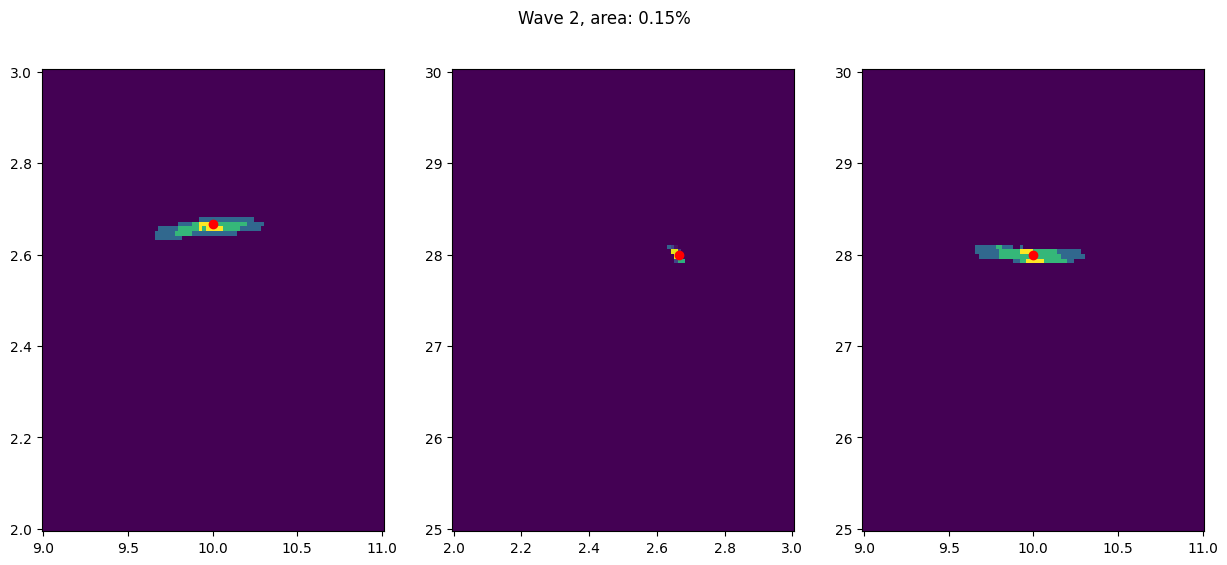

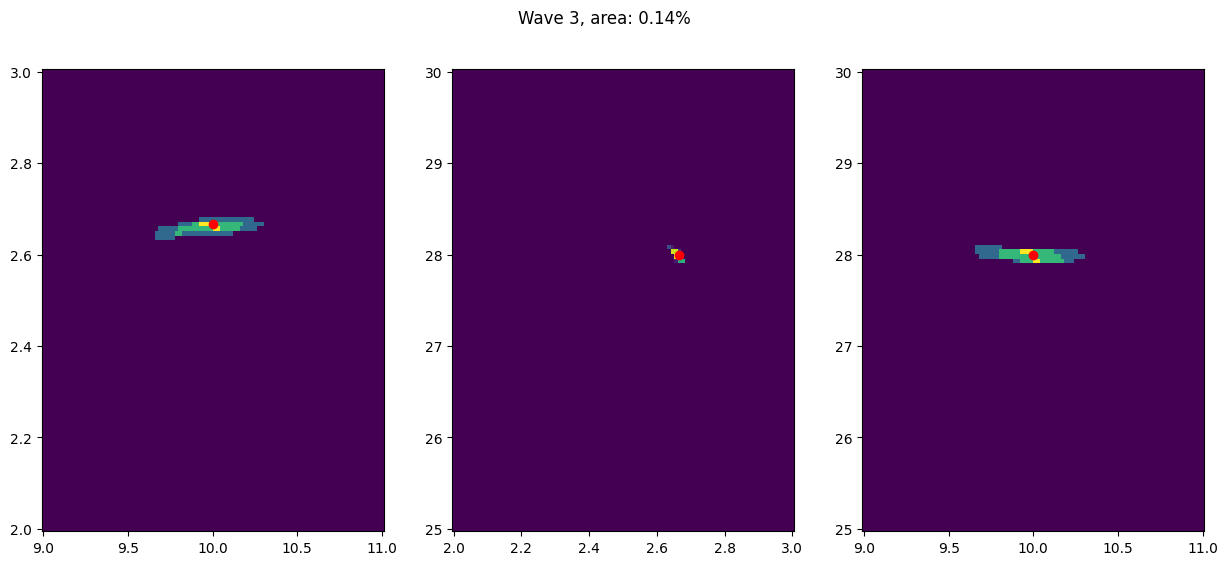

In [15]:
import matplotlib.pyplot as plt
for wave in range(1,4):
    nroy,coords = hm.nroy_over_support(wave,return_coords=True)
    area = hm.estimate_nroy_volume(wave)
    fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,6))
    fig.suptitle(f'Wave {wave}, area: {area.item()*100:.2f}%')
    X,Y = torch.meshgrid(coords[0],coords[1],indexing='xy')
    ax1.pcolormesh(X,Y,nroy.sum(dim=2).T/100)
    ax1.scatter(params['sigma'],params['beta'],color='r')

    X,Y = torch.meshgrid(coords[1],coords[2],indexing='xy')
    ax2.pcolormesh(X,Y,nroy.sum(dim=0).T/100)
    ax2.scatter(params['beta'],params['rho'],color='r')
    X,Y = torch.meshgrid(coords[0],coords[2],indexing='xy')
    ax3.pcolormesh(X,Y,nroy.sum(dim=1).T/100)
    ax3.scatter(params['sigma'],params['rho'],color='r')

<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:8: SyntaxWarning: invalid escape sequence '\{'
<>:13: SyntaxWarning: invalid escape sequence '\{'
<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:18: SyntaxWarning: invalid escape sequence '\{'
<>:19: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarn

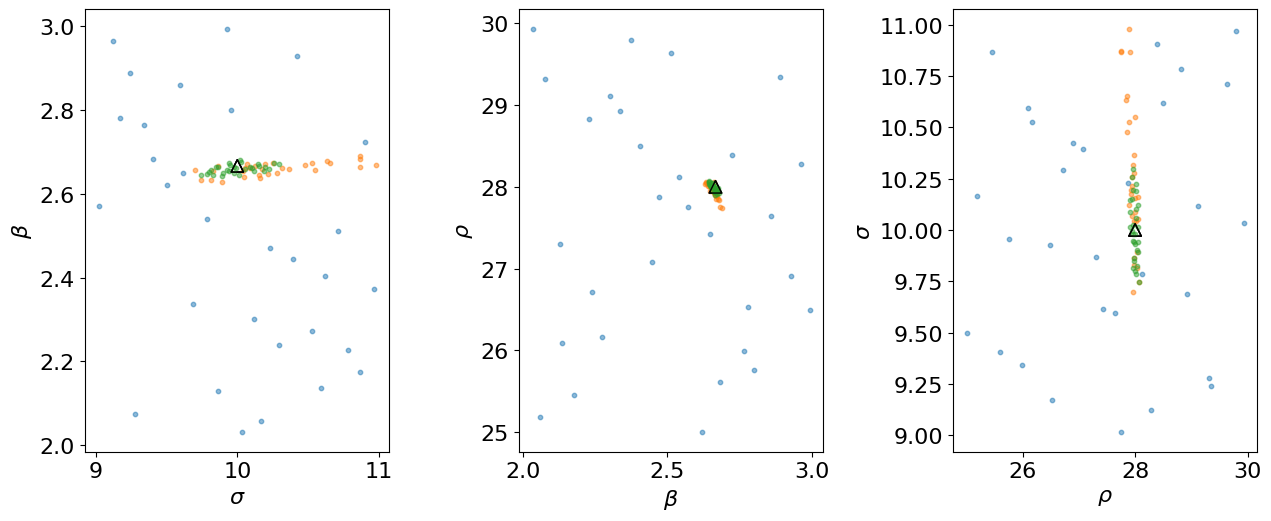

In [19]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(13,5.5))
plt.rcParams.update({'font.size': 16})
with torch.no_grad():
    for p in hm.params:
        ax1.scatter(p[:, 0], p[:, 1], alpha=0.5, s=10)
        ax1.scatter(params['sigma'],params['beta'],color='none',marker='^',s=80,edgecolor='black')
        ax1.set_xlabel(f"$\{parameters[0]}$")
        ax1.set_ylabel(f"$\{parameters[1]}$")


        ax2.scatter(p[:, 1], p[:, 2], alpha=0.5, s=10)
        ax2.scatter(params['beta'],params['rho'],color='none',marker='^',s=80,edgecolor='black')
        ax2.set_xlabel(f"$\{parameters[1]}$")
        ax2.set_ylabel(f"$\{parameters[2]}$")

        ax3.scatter(p[:, 2], p[:, 0], alpha=0.5, s=10)
        ax3.scatter(params['rho'],params['sigma'],color='none',marker='^',s=80,edgecolor='black')
        ax3.set_xlabel(f"$\{parameters[2]}$")
        ax3.set_ylabel(f"$\{parameters[0]}$")
fig.tight_layout()
fig.savefig('lorenz63_hm.png',dpi=300) 

#### CES method
We have done _calibration_ and _emulation_, now time to sample, assuming a gaussian prior.
Assuming time average $G_{\tau}(\theta;z_0) \approx G(\theta)$ (notation from )
$$
z = f(\theta) + \eta
$$
Assume that the residual is _Gaussian_ (probably is not):

$$
z - f(\theta) = r 
$$
Therefore for $z,f \in \mathbf{R}^k, \Gamma \in \mathbf{R}^{k\times k}$:
$$
p(r) = \frac{1}{\sqrt{(2 \pi)^k \det \Gamma(\theta)}} \exp\left(-\frac{1}{2} (z - f(\theta)^T (\Gamma(\theta))^{-1} (z-f(\theta))\right)
$$

Use this as a liklihood that is $ L(\theta) = p(z | \theta)$.
Then through bayes rule:
$$
p(\theta | z, X, y) = \frac{p(z | \theta, X, y)*p(\theta)}{p(z| X, y)} 


In [108]:
em = hm.emulators[-1]
coords = hm.get_support_axis(num_points=100)


## visualize the liklihood with one out. 
(i.e 2D but let the missing value take on the _true_ value)




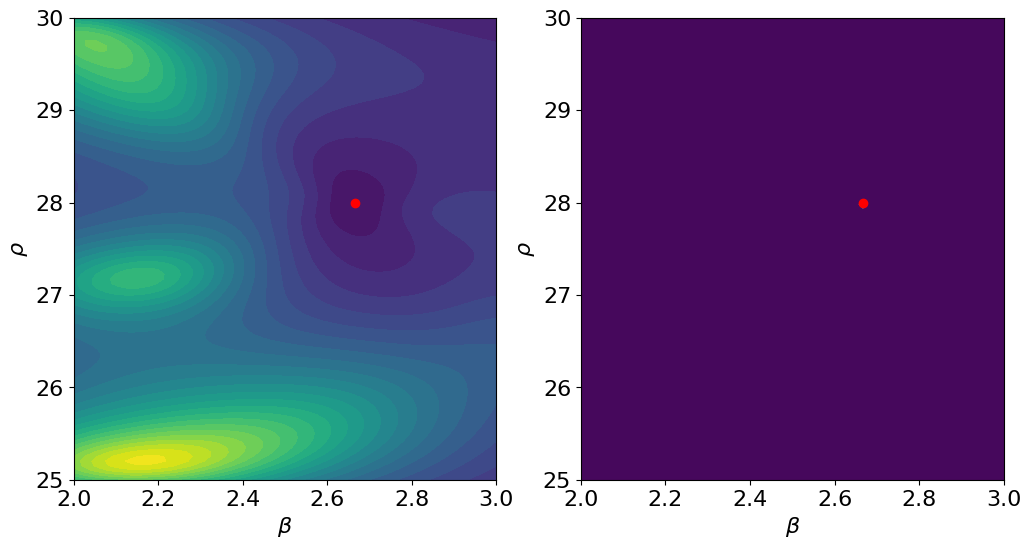

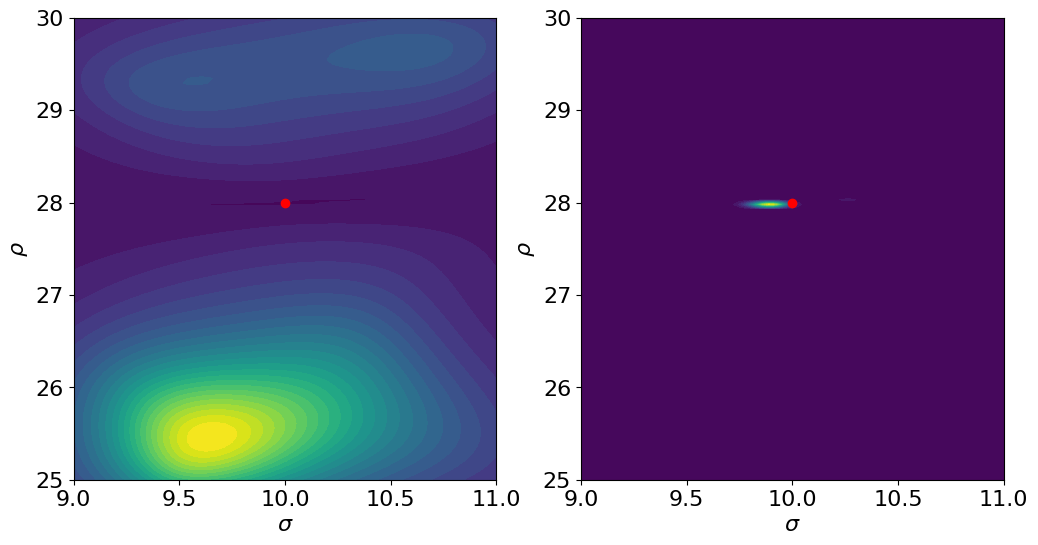

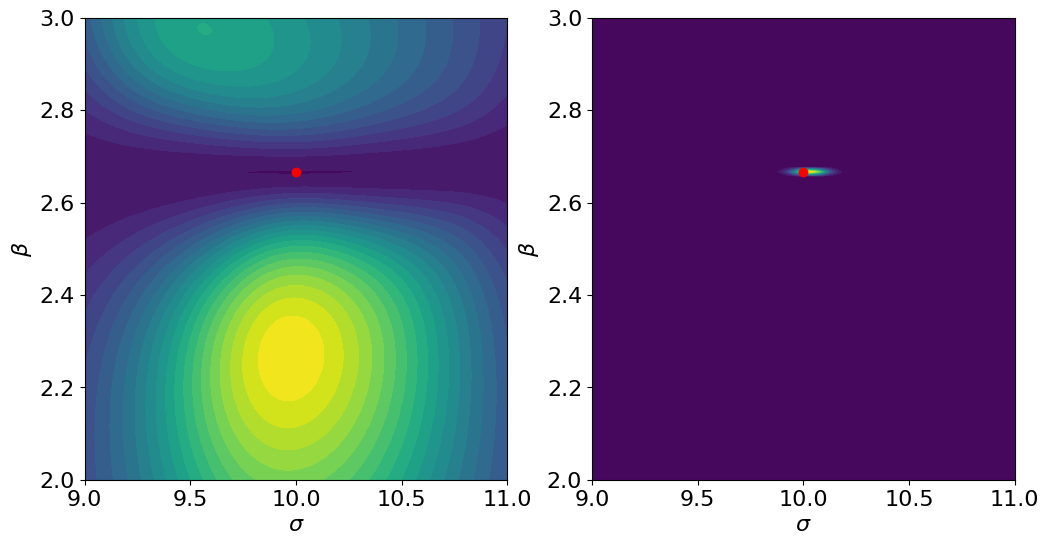

In [111]:
from gpytorch.settings import fast_pred_var

def lazy_task_covar(lazy_covar,ntasks,npoints):
    task_covar = torch.zeros(npoints,ntasks,ntasks)
    for i in range(npoints):
        task_covar[i] = lazy_covar[i*ntasks:(i+1)*ntasks,i*ntasks:(i+1)*ntasks].evaluate()
    return task_covar
## SIGMA OUT

def misfit_GP(mean,covar):
    return 0.5*torch.linalg.vecdot(mean,torch.linalg.solve(covar + stats.covariance_matrix,mean)) + 0.5*torch.logdet(covar+stats.covariance_matrix)


fig,(axnegll,axl)  = plt.subplots(1,2,figsize=(12,6))
X,Y = torch.meshgrid(coords[1],coords[2],indexing='xy')
sigma = torch.ones_like(X)*params['sigma']
points = torch.stack([sigma,X,Y],dim=-1).reshape(-1,3)
with torch.no_grad(), fast_pred_var():
    predictions = em(points)
    task_covar = lazy_task_covar(predictions.lazy_covariance_matrix,9,100*100).view(*X.shape,9,9)
    mean = predictions.mean.detach().reshape((*X.shape,9))

    misfit = misfit_GP(mean,task_covar)
    liklihood = (-1*misfit).exp()
    axnegll.contourf(X,Y,misfit,levels=25)
    axnegll.scatter(params['beta'],params['rho'],color='r')
    axnegll.set_xlabel('$\\beta$')
    axnegll.set_ylabel('$\\rho$')

    axl.contourf(X,Y,liklihood,levels=25)
    axl.scatter(params['beta'],params['rho'],color='r')
    axl.set_xlabel('$\\beta$')
    axl.set_ylabel('$\\rho$')

## SET BETA

fig,(axnegll,axl)  = plt.subplots(1,2,figsize=(12,6))
X,Y = torch.meshgrid(coords[0],coords[2],indexing='xy')
beta = torch.ones_like(X)*params['beta']
points = torch.stack([X,beta,Y],dim=-1).reshape(-1,3)
with torch.no_grad(), fast_pred_var():
    predictions = em(points)
    task_covar = lazy_task_covar(predictions.lazy_covariance_matrix,9,100*100).view(*X.shape,9,9)
    mean = predictions.mean.detach().reshape((*X.shape,9))

    misfit = misfit_GP(mean,task_covar)
    liklihood = (-1*misfit).exp()
    axnegll.contourf(X,Y,misfit,levels=25)
    axnegll.scatter(params['sigma'],params['rho'],color='r')
    axnegll.set_xlabel('$\\sigma$')
    axnegll.set_ylabel('$\\rho$')

    axl.contourf(X,Y,liklihood,levels=25)
    axl.scatter(params['sigma'],params['rho'],color='r')
    axl.set_xlabel('$\\sigma$')
    axl.set_ylabel('$\\rho$')

## SET RHO

fig,(axnegll,axl)  = plt.subplots(1,2,figsize=(12,6))
X,Y = torch.meshgrid(coords[0],coords[1],indexing='xy')
rho = torch.ones_like(X)*params['rho']
points = torch.stack([X,Y,rho],dim=-1).reshape(-1,3)
with torch.no_grad(), fast_pred_var():
    predictions = em(points)
    task_covar = lazy_task_covar(predictions.lazy_covariance_matrix,9,100*100).view(*X.shape,9,9)
    mean = predictions.mean.detach().reshape((*X.shape,9))

    misfit = misfit_GP(mean,task_covar)
    liklihood = (-1*misfit).exp()
    axnegll.contourf(X,Y,misfit,levels=25)
    axnegll.scatter(params['sigma'],params['beta'],color='r')
    axnegll.set_xlabel('$\\sigma$')
    axnegll.set_ylabel('$\\beta$')

    axl.contourf(X,Y,liklihood,levels=25)
    axl.scatter(params['sigma'],params['beta'],color='r')
    axl.set_xlabel('$\\sigma$')
    axl.set_ylabel('$\\beta$')

In [ ]:
def pdf(x,u:torch.distributions.Distribution):
    pdf_val = torch.zeros(x.shape)
    in_support = u.support.check(x)
    pdf_val[in_support] = u.log_prob(x[in_support]).exp()
    return pdf_val



tensor([0.5000])

In [247]:
from torch.distributions import Normal
em = hm.emulators[0]
def liklihood(x,em):
    with fast_pred_var():
        pred = em(x)
        mean = pred.mean
        task_covar = lazy_task_covar(pred.lazy_covariance_matrix,pred.num_tasks,pred.event_shape[0])
        misfit = misfit_GP(mean,task_covar)
        return (-1*misfit).exp()    

CHAIN_LENGTH = 1000
BURN_IN = 5000
DELTA_PER_DIM = 0.025

norm = Normal(torch.zeros(3), torch.tensor([ p.stddev*DELTA_PER_DIM for p in hm.prior_list]) )

initial_point = hm.params[-1,0]
chain = torch.zeros(CHAIN_LENGTH + BURN_IN,3)
chain[0] = initial_point
ratio = torch.zeros(CHAIN_LENGTH + BURN_IN)
ratio[0] = 1
for i in range(1,CHAIN_LENGTH + BURN_IN):
    delta = norm.sample()
    proposal = chain[i-1] + delta
    acceptance_ratio = torch.min(torch.tensor(1),liklihood(proposal.view(-1,3),em)/liklihood(chain[i-1].view(-1,3),em))
    ratio[i] = acceptance_ratio 
    if acceptance_ratio > torch.rand(1):
        chain[i] = proposal
    else:
        chain[i] = chain[i-1]

ratio.mean()

    

tensor(0.2647, grad_fn=<MeanBackward0>)

(25.0, 30.0)

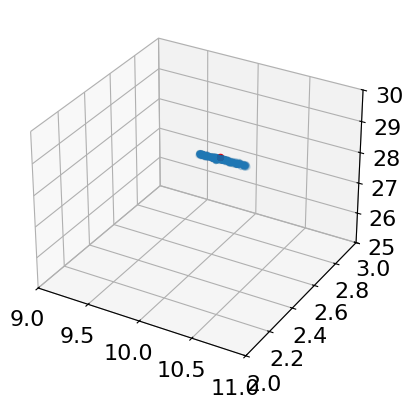

In [249]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(chain[BURN_IN:,0],chain[BURN_IN:,1],chain[BURN_IN:,2],alpha=0.05)
ax.scatter(params['sigma'],params['beta'],params['rho'],color='r')
ax.set_xlim(hm.prior_list[0].support.lower_bound,hm.prior_list[0].support.upper_bound)
ax.set_ylim(hm.prior_list[1].support.lower_bound,hm.prior_list[1].support.upper_bound)
ax.set_zlim(hm.prior_list[2].support.lower_bound,hm.prior_list[2].support.upper_bound)



## Ensemble Kalman Inversion (L63)

In [ ]:
from abracalibra.eki import EnsembleKalmanInversion

eki = EnsembleKalmanInversion(parameters,priors,stats,ensemble_size=30,forward=fwd)
eki.calibrate(3)

tensor([ 9.9833,  2.6676, 28.0033], grad_fn=<MeanBackward1>)

<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:8: SyntaxWarning: invalid escape sequence '\{'
<>:13: SyntaxWarning: invalid escape sequence '\{'
<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:18: SyntaxWarning: invalid escape sequence '\{'
<>:19: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarn

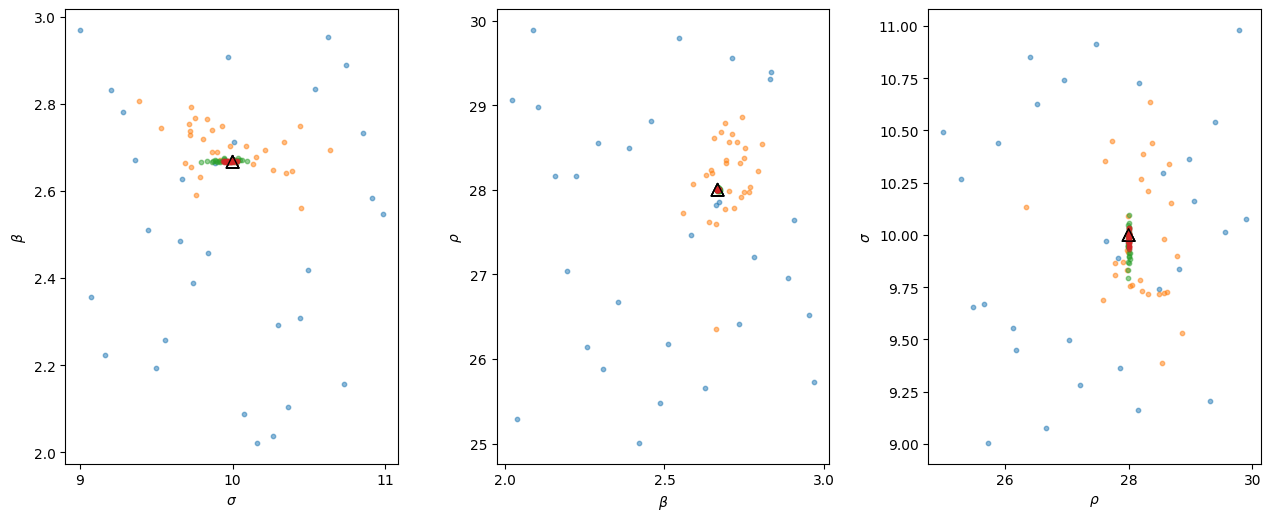

In [ ]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(13,5.5))
plt.rcParams.update({'font.size': 16})
with torch.no_grad():
    for p in eki.parameters:
        ax1.scatter(p[:, 0], p[:, 1], alpha=0.5, s=10)
        ax1.scatter(params['sigma'],params['beta'],color='none',marker='^',s=80,edgecolor='black')
        ax1.set_xlabel(f"$\{parameters[0]}$")
        ax1.set_ylabel(f"$\{parameters[1]}$")


        ax2.scatter(p[:, 1], p[:, 2], alpha=0.5, s=10)
        ax2.scatter(params['beta'],params['rho'],color='none',marker='^',s=80,edgecolor='black')
        ax2.set_xlabel(f"$\{parameters[1]}$")
        ax2.set_ylabel(f"$\{parameters[2]}$")

        ax3.scatter(p[:, 2], p[:, 0], alpha=0.5, s=10)
        ax3.scatter(params['rho'],params['sigma'],color='none',marker='^',s=80,edgecolor='black')
        ax3.set_xlabel(f"$\{parameters[2]}$")
        ax3.set_ylabel(f"$\{parameters[0]}$")
fig.tight_layout()
fig.savefig('lorenz63_eki.png',dpi=300) 